<div align="center">

<h1> <b> MODELO DE DEPOSICIÓN ALEATORIA PARA EL CRECIMIENTO DE PELÍCULAS DELGADAS </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Cristian Vergara <br>
Juan Palacio <br>
Sofía Moscoso <br>
Lucas Perdomo</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---

## 1. Introducción y objetivos

Este proyecto estudia qué procesos físicos determinan la morfología y la estructura final de una película delgada de cobre (Cu) depositada sobre vidrio por evaporación térmica en una cámara de vacío. En lugar de construir desde el inicio un simulador con todos los mecanismos presentes, se sigue una estrategia incremental habitual en física computacional: los mecanismos físicos se aíslan y se añaden uno a uno en cuadernos independientes, de modo que el efecto de cada uno sobre la morfología pueda distinguirse.

Este primer cuaderno trata el modelo más simple posible, la **deposición aleatoria** (*random deposition*, RD; Barabási & Stanley, 1995, cap. 4). Las partículas llegan de forma perpendicular al sustrato y quedan fijas en la celda donde impactan, sin rebotar ni difundir. Este escenario es ideal y no describe un experimento real, pero ofrece una línea base estadística con solución analítica, útil para validar el método Monte Carlo antes de incorporar física adicional como la difusión superficial, la temperatura o la presión.

### Objetivos

* Implementar el algoritmo de deposición aleatoria sobre una malla bidimensional discreta mediante números pseudoaleatorios.
* Reducir el tiempo de cómputo del ciclo Monte Carlo compilándolo con Numba (Lam et al., 2015).
* Validar el simulador comparando el espesor medio y la rugosidad con las predicciones analíticas de la estadística de Poisson.

## 2. Marco teórico y modelo físico

### 2.1 Modelo de deposición aleatoria

El sustrato y el material acumulado se describen con la aproximación *solid-on-solid* (SOS), en la que la superficie queda definida por una única altura en cada posición, sin huecos ni voladizos (Barabási & Stanley, 1995). Se emplea una malla discreta de $N_x \times N_y$ celdas. Cada celda $(i, j)$ representa una columna de sección fija sobre el sustrato y almacena un entero $h(i, j)$ que cuenta las capas efectivas de material apiladas en ella.

Cada evento de Monte Carlo deposita una partícula en una celda $(i, j)$ elegida con probabilidad uniforme $1/(N_x N_y)$. Como no hay relajación superficial, la partícula permanece donde cae:

$$h(i, j) \leftarrow h(i, j) + 1.$$

Cada partícula añade exactamente una capa, por lo que $h$ es un conteo sin dimensiones físicas: las capas de una celda coinciden con el número de partículas que ha recibido. El tiempo se mide en eventos de Monte Carlo, es decir, en partículas depositadas.

### 2.2 Magnitudes de caracterización morfológica

La evolución de la película se caracteriza con dos magnitudes, ambas expresadas en capas. El **espesor medio** es la altura promedio sobre toda la malla:

$$\overline{h} = \frac{1}{N_x N_y} \sum_{i=0}^{N_x-1} \sum_{j=0}^{N_y-1} h(i, j).$$

La **rugosidad RMS** es la desviación estándar de las alturas y mide cuán irregular es la superficie:

$$W = \sqrt{\frac{1}{N_x N_y} \sum_{i=0}^{N_x-1} \sum_{j=0}^{N_y-1} \left(h(i, j) - \overline{h}\right)^2}.$$

### 2.3 Predicciones analíticas

Sea $M = N_x N_y$ el número de celdas y $N$ el número de eventos.

#### Espesor medio

Cada evento añade una capa a la malla, de modo que $\sum h = N$ y

$$\overline{h}_{\mathrm{teo}} = \frac{N}{M}.$$

Esta relación es exacta y expresa la conservación del número de partículas: el espesor medio crece linealmente con $N$.

#### Rugosidad

Las celdas son equiprobables y los eventos independientes, de modo que el número de partículas que recibe una celda sigue una distribución binomial $B(N, 1/M)$. Para $M \gg 1$ esta se aproxima por una distribución de Poisson de media $\lambda = N/M$ (Barabási & Stanley, 1995, cap. 4), cuya varianza es igual a su media. Como $W$ es la desviación estándar de las alturas,

$$W_{\mathrm{teo}} = \sqrt{\overline{h}} = \sqrt{\frac{N}{N_x N_y}}.$$

Si el tiempo se mide en capas depositadas, $t = \overline{h}$, la rugosidad crece como $t^{1/2}$ y no satura. En el marco del escalamiento dinámico de Family y Vicsek (1985), esto corresponde a un exponente de crecimiento $\beta = 1/2$ (Barabási & Stanley, 1995) y refleja que ningún mecanismo correlaciona celdas vecinas ni redistribuye material entre ellas.

Las relaciones anteriores están escritas en capas. Si cada capa tiene un espesor $a$, la rugosidad en unidades de longitud es $a\,W_{\mathrm{teo}}$, con $\overline{h}$ dentro de la raíz aún medido en capas.

#### Fluctuación de una realización

La rugosidad calculada sobre una única realización fluctúa alrededor de $W_{\mathrm{teo}}$. Con el número total de partículas fijo, las alturas siguen una distribución multinomial y la varianza de $W^2$ es $2\overline{h}^2/M$ para $M \gg 1$. Por propagación de errores,

$$\sigma_W \approx \frac{W_{\mathrm{teo}}}{\sqrt{2M}}.$$

Esta desviación típica es la referencia para decidir si la diferencia entre la rugosidad simulada y la teórica es compatible con el azar. Para la malla de $200 \times 200$ celdas de este cuaderno equivale a una desviación relativa de $0.35\,\%$.

Físicamente se espera una superficie muy rugosa, con columnas altas y valles profundos, ya que ningún proceso (difusión, activación térmica) suaviza el relieve.

## 3. Librerías y configuración

El cálculo numérico usa NumPy (Harris et al., 2020). Los ciclos de deposición y de cálculo de métricas se compilan con Numba (Lam et al., 2015) cuando la librería está instalada; si no lo está, las mismas funciones se ejecutan como Python puro, con más lentitud pero con las mismas propiedades estadísticas. SciPy (Virtanen et al., 2020) aporta las distribuciones de referencia para las figuras y Matplotlib (Hunter, 2007) se encarga de la visualización.

Numba mantiene un generador de números pseudoaleatorios propio, con un estado independiente del de NumPy: sembrar uno no modifica al otro (Numba, s. f.). Por ello la semilla se fija dentro de la función de simulación (sección 5) y no en esta celda. Las secuencias de Numba y de NumPy no tienen por qué coincidir para una misma semilla, de manera que una realización concreta solo es reproducible dentro de un mismo modo de ejecución.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, poisson

# Numba es una dependencia opcional de aceleración. Si no está instalada, las
# funciones numéricas se ejecutan sin compilar: el resultado es estadísticamente
# equivalente, aunque más lento.
try:
    from numba import njit
    NUMBA_DISPONIBLE = True
except ImportError:
    NUMBA_DISPONIBLE = False

    def njit(*args, **kwargs):
        """Sustituto de ``numba.njit`` que deja la función sin compilar.

        Admite tanto la forma ``@njit`` como la forma ``@njit(...)``.
        """
        if len(args) == 1 and callable(args[0]) and not kwargs:
            return args[0]

        def decorador(funcion):
            return funcion

        return decorador

if not NUMBA_DISPONIBLE:
    print("Numba no está disponible: la simulación se ejecutará en Python puro (más lenta).")

# Estilo de las figuras. La resolución de guardado (300 dpi) es la adecuada
# para insertarlas en un informe.
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'font.family': 'serif',
    'figure.dpi': 120,
    'savefig.dpi': 300
})

## 4. Parámetros del sistema

Las dimensiones de la malla se dan en celdas, el número de eventos en partículas depositadas y las alturas en capas. Con los valores de referencia, cada celda recibe en promedio $N/(N_x N_y) = 10$ partículas, un valor suficientemente grande para que la distribución de Poisson resultante sea reconocible en el histograma de alturas.

In [12]:
# Dimensiones del sustrato (número de celdas en cada dirección)
NX = 200
NY = 200

# Parámetros del método Monte Carlo, ambos en eventos (una partícula por evento).
# Con estos valores cada celda recibe en promedio N_EVENTOS / (NX * NY) = 10 partículas.
N_EVENTOS = 400_000
GUARDAR_CADA = 2_000   # intervalo de muestreo de la evolución temporal

# Semilla del generador pseudoaleatorio (ver sección 3)
SEMILLA = 42

## 5. Funciones del modelo

La función `calcular_metricas_numba` obtiene $\overline{h}$ y $W$ con dos recorridos de la malla: primero la media y después las desviaciones respecto a ella. Este esquema evita la cancelación numérica que aparece al restar $\langle h^2 \rangle - \langle h \rangle^2$ cuando la media es grande frente a la dispersión.

La función `ejecutar_simulacion` implementa el ciclo Monte Carlo y registra las métricas cada `guardar_cada` eventos. El ciclo es secuencial: todos los eventos modifican la misma matriz de alturas y las métricas se muestrean sobre el estado acumulado, de modo que repartirlo entre hilos introduciría condiciones de carrera (dos hilos podrían incrementar la misma celda a la vez) y complicaría la reproducibilidad de la secuencia aleatoria.

In [13]:
@njit
def calcular_metricas_numba(superficie, nx, ny):
    """Calcula el espesor medio y la rugosidad RMS de una superficie.

    Parámetros
    ----------
    superficie : ndarray de enteros, forma (nx, ny)
        Altura de cada celda, en capas.
    nx, ny : int
        Número de celdas en cada dirección.

    Devuelve
    --------
    espesor : float
        Altura media, en capas.
    rugosidad : float
        Desviación estándar poblacional de las alturas (divisor nx * ny), en capas.
    """
    # Se calcula primero la media y después las desviaciones respecto a ella
    # (dos pasadas). Restar <h^2> - <h>^2 en una sola pasada perdería precisión
    # cuando la media es grande frente a la dispersión.
    suma_alturas = 0.0
    for i in range(nx):
        for j in range(ny):
            suma_alturas += superficie[i, j]
    espesor = suma_alturas / (nx * ny)

    suma_varianza = 0.0
    for i in range(nx):
        for j in range(ny):
            diferencia = superficie[i, j] - espesor
            suma_varianza += diferencia * diferencia
    rugosidad = np.sqrt(suma_varianza / (nx * ny))

    return espesor, rugosidad

In [14]:
@njit
def ejecutar_simulacion(nx, ny, n_eventos, guardar_cada, semilla):
    """Ejecuta la deposición aleatoria Monte Carlo sobre una malla nx x ny.

    Cada evento deposita una partícula en una celda elegida con probabilidad
    uniforme. La altura de esa celda aumenta en una capa y no hay relajación
    posterior.

    Parámetros
    ----------
    nx, ny : int
        Número de celdas en cada dirección.
    n_eventos : int
        Número total de eventos, igual al número de partículas depositadas.
    guardar_cada : int
        Intervalo de muestreo, en eventos, de las métricas temporales.
    semilla : int
        Semilla del generador pseudoaleatorio.

    Devuelve
    --------
    superficie : ndarray int32, forma (nx, ny)
        Alturas finales, en capas.
    historial_eventos : ndarray int32
        Número de eventos transcurridos en cada muestreo.
    historial_espesor, historial_rugosidad : ndarray float64
        Espesor medio y rugosidad RMS, en capas, en cada muestreo.
    """
    if nx <= 0 or ny <= 0:
        raise ValueError("nx y ny deben ser positivos.")
    if guardar_cada <= 0 or guardar_cada > n_eventos:
        raise ValueError("Se requiere 0 < guardar_cada <= n_eventos.")

    # En Numba, np.random.seed solo actúa sobre el generador de Numba si se
    # llama dentro de una función compilada; por eso la semilla se fija aquí.
    np.random.seed(semilla)

    superficie = np.zeros((nx, ny), dtype=np.int32)

    # Arreglos de tamaño fijo para el historial: evitan crecer listas dentro
    # del ciclo compilado.
    tamano_historial = n_eventos // guardar_cada
    historial_eventos = np.zeros(tamano_historial, dtype=np.int32)
    historial_espesor = np.zeros(tamano_historial, dtype=np.float64)
    historial_rugosidad = np.zeros(tamano_historial, dtype=np.float64)

    contador = 0
    for evento in range(1, n_eventos + 1):
        # Celda de impacto, equiprobable e independiente de la altura actual.
        x = np.random.randint(0, nx)
        y = np.random.randint(0, ny)

        # Deposición directa, sin relajación ni movimiento superficial.
        superficie[x, y] += 1

        # Las métricas se evalúan sobre el estado acumulado de la superficie.
        if evento % guardar_cada == 0:
            esp, rug = calcular_metricas_numba(superficie, nx, ny)
            historial_eventos[contador] = evento
            historial_espesor[contador] = esp
            historial_rugosidad[contador] = rug
            contador += 1

    return superficie, historial_eventos, historial_espesor, historial_rugosidad

## 6. Ejecución y validación analítica

Se ejecuta la simulación con los parámetros de la sección 4 y se comparan el espesor medio, la rugosidad y los extremos de altura con las predicciones de la sección 2.3. La rugosidad simulada se juzga con la variable $z = (W_{\mathrm{sim}} - W_{\mathrm{teo}})/\sigma_W$, y se considera compatible con la predicción de Poisson cuando $|z| \leq 3$.

In [15]:
print("Ejecutando la simulación Monte Carlo...")

superficie_final, eventos, hist_espesor, hist_rugosidad = ejecutar_simulacion(
    NX, NY, N_EVENTOS, GUARDAR_CADA, SEMILLA
)

print("Simulación finalizada.")

# Métricas finales de la malla
espesor_sim = np.mean(superficie_final)
rugosidad_sim = np.std(superficie_final)
alt_maxima = np.max(superficie_final)
alt_minima = np.min(superficie_final)
celdas_vacias_sim = int(np.sum(superficie_final == 0))
celdas_max_sim = int(np.sum(superficie_final >= alt_maxima))

# Cada evento añade exactamente una capa: si la suma de alturas no coincide con
# el número de eventos, el resultado es incorrecto aunque no se lance ninguna excepción.
if superficie_final.sum() != N_EVENTOS:
    raise RuntimeError("La suma de alturas no coincide con el número de partículas depositadas.")

# Predicciones analíticas (sección 2.3)
n_celdas = NX * NY
espesor_teo = N_EVENTOS / n_celdas
rugosidad_teo = np.sqrt(espesor_teo)
sigma_rugosidad = rugosidad_teo / np.sqrt(2 * n_celdas)             # fluctuación de W en una realización
celdas_vacias_teo = n_celdas * poisson.pmf(0, espesor_teo)          # celdas esperadas con h = 0
celdas_max_teo = n_celdas * poisson.sf(alt_maxima - 1, espesor_teo)  # celdas esperadas con h >= h_max

Ejecutando la simulación Monte Carlo...
Simulación finalizada.


In [16]:
error_espesor = abs(espesor_sim - espesor_teo) / espesor_teo * 100
error_rugosidad = abs(rugosidad_sim - rugosidad_teo) / rugosidad_teo * 100
z_rugosidad = (rugosidad_sim - rugosidad_teo) / sigma_rugosidad

ANCHO = 66


def fila(etiqueta, valor):
    print(f"{etiqueta:<35}: {valor}")


print("=" * ANCHO)
print("MÉTRICAS DEL CRECIMIENTO DE LA PELÍCULA".center(ANCHO))
print("=" * ANCHO)
fila("Dimensiones del sustrato", f"{NX} x {NY} celdas")
fila("Partículas totales depositadas", N_EVENTOS)
fila("Altura máxima alcanzada", f"{alt_maxima} capas")
fila("Altura mínima alcanzada", f"{alt_minima} capas")
print("-" * ANCHO)
fila("Espesor medio simulado", f"{espesor_sim:.4f} capas")
fila("Espesor medio teórico", f"{espesor_teo:.4f} capas")
fila("Error relativo (espesor)", f"{error_espesor:.4f} %")
print("-" * ANCHO)
fila("Rugosidad RMS simulada", f"{rugosidad_sim:.4f} capas")
fila("Rugosidad RMS teórica", f"{rugosidad_teo:.4f} capas")
fila("Error relativo (rugosidad)", f"{error_rugosidad:.4f} %")
fila("Fluctuación esperada de W (1 σ)", f"{sigma_rugosidad:.4f} capas ({100 * sigma_rugosidad / rugosidad_teo:.2f} %)")
fila("Desviación z de la rugosidad", f"{z_rugosidad:+.2f}")
print("-" * ANCHO)
fila("Celdas con h = 0 (sim. / teoría)", f"{celdas_vacias_sim} / {celdas_vacias_teo:.1f}")
fila(f"Celdas con h >= {alt_maxima} (sim. / teoría)", f"{celdas_max_sim} / {celdas_max_teo:.2f}")
print("=" * ANCHO)

if abs(z_rugosidad) <= 3:
    print("La rugosidad es compatible con la predicción de Poisson (|z| <= 3).")
else:
    print("La rugosidad se aparta de la predicción de Poisson (|z| > 3): revisar el generador y el algoritmo.")

             MÉTRICAS DEL CRECIMIENTO DE LA PELÍCULA              
Dimensiones del sustrato           : 200 x 200 celdas
Partículas totales depositadas     : 400000
Altura máxima alcanzada            : 26 capas
Altura mínima alcanzada            : 0 capas
------------------------------------------------------------------
Espesor medio simulado             : 10.0000 capas
Espesor medio teórico              : 10.0000 capas
Error relativo (espesor)           : 0.0000 %
------------------------------------------------------------------
Rugosidad RMS simulada             : 3.1559 capas
Rugosidad RMS teórica              : 3.1623 capas
Error relativo (rugosidad)         : 0.2005 %
Fluctuación esperada de W (1 σ)    : 0.0112 capas (0.35 %)
Desviación z de la rugosidad       : -0.57
------------------------------------------------------------------
Celdas con h = 0 (sim. / teoría)   : 4 / 1.8
Celdas con h >= 26 (sim. / teoría) : 1 / 0.71
La rugosidad es compatible con la predicción de Poisson 

## 7. Visualización de resultados

Las figuras muestran la topografía de la película, la distribución de alturas frente a las distribuciones teóricas, la evolución temporal de las métricas y un perfil unidimensional. Además de mostrarse en el cuaderno, cada figura se guarda como archivo PNG en el directorio de trabajo.

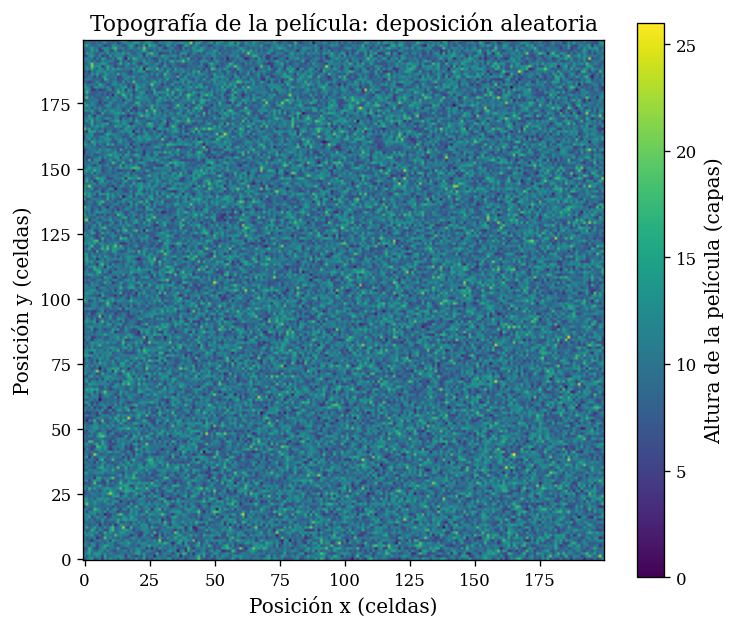

In [17]:
# Topografía bidimensional de la película (mapa de alturas)
fig, ax = plt.subplots(figsize=(7, 6))
# Se transpone la matriz para que el eje horizontal sea x (primer índice de la
# malla) y el vertical sea y (segundo índice); imshow dibuja el primer índice en vertical.
imagen = ax.imshow(superficie_final.T, origin="lower", cmap="viridis")
fig.colorbar(imagen, ax=ax, label="Altura de la película (capas)")
ax.set_xlabel("Posición x (celdas)")
ax.set_ylabel("Posición y (celdas)")
ax.set_title("Topografía de la película: deposición aleatoria")
fig.savefig("rd_topografia_superficie.png", bbox_inches="tight")
plt.show()

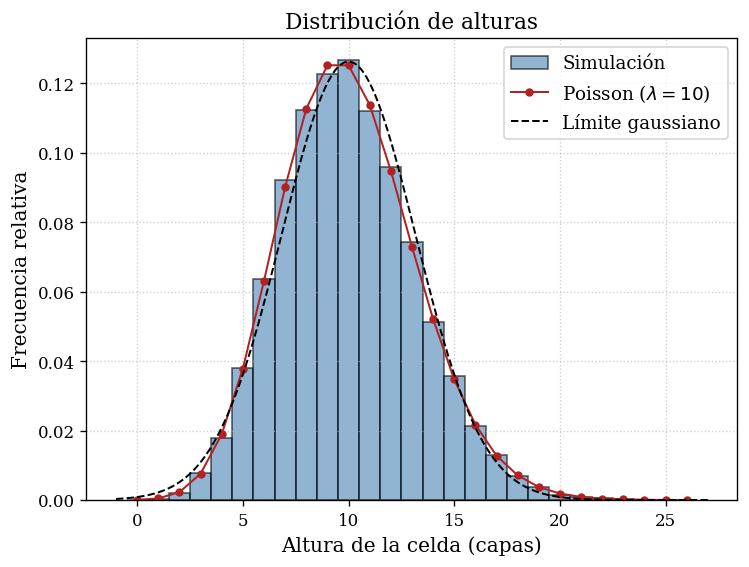

In [18]:
# Distribución de alturas frente a la estadística de Poisson
# Un intervalo de anchura unidad centrado en cada altura entera: con density=True,
# la altura de cada barra es la frecuencia relativa de esa altura.
bordes = np.arange(alt_minima, alt_maxima + 2) - 0.5
alturas_enteras = np.arange(alt_minima, alt_maxima + 1)
alturas_continuas = np.linspace(alt_minima - 1, alt_maxima + 1, 400)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(
    superficie_final.ravel(),
    bins=bordes,
    density=True,
    edgecolor="black",
    alpha=0.6,
    color="steelblue",
    label="Simulación",
)
# Las curvas de referencia usan los parámetros teóricos (media y varianza iguales
# a h_teo), no los de la simulación; así la comparación pone a prueba el modelo
# en lugar de ajustarse a los datos.
ax.plot(
    alturas_enteras,
    poisson.pmf(alturas_enteras, espesor_teo),
    "o-",
    color="firebrick",
    markersize=4,
    linewidth=1.2,
    label=rf"Poisson ($\lambda = {espesor_teo:g}$)",
)
ax.plot(
    alturas_continuas,
    norm.pdf(alturas_continuas, espesor_teo, rugosidad_teo),
    "k--",
    linewidth=1.2,
    label="Límite gaussiano",
)
ax.set_xlabel("Altura de la celda (capas)")
ax.set_ylabel("Frecuencia relativa")
ax.set_title("Distribución de alturas")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()
fig.savefig("rd_histograma_alturas.png", bbox_inches="tight")
plt.show()

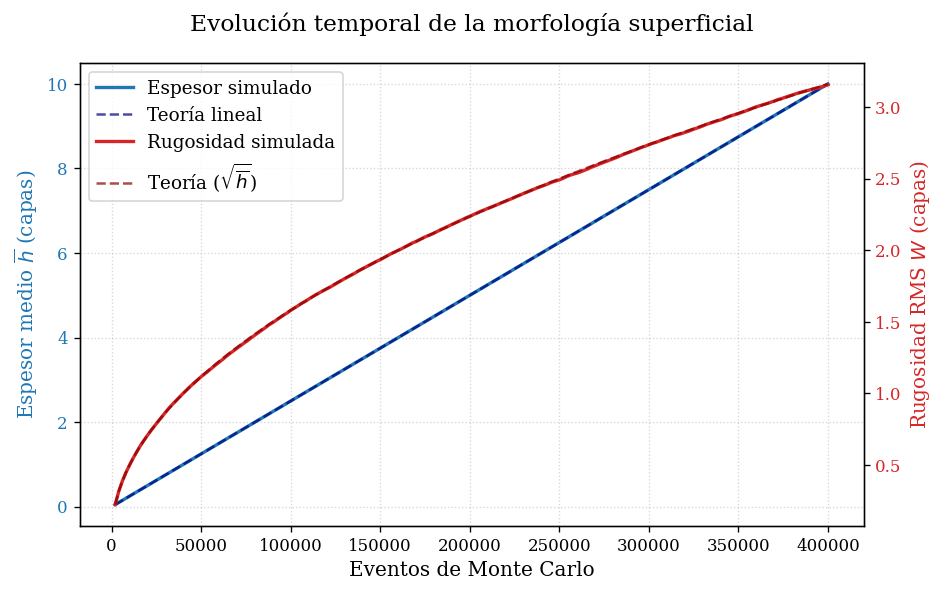

In [19]:
# Evolución temporal del espesor medio y de la rugosidad
fig, ax1 = plt.subplots(figsize=(8, 5))

color_esp = "tab:blue"
ax1.set_xlabel("Eventos de Monte Carlo")
ax1.set_ylabel(r"Espesor medio $\overline{h}$ (capas)", color=color_esp)
ax1.plot(eventos, hist_espesor, label="Espesor simulado", color=color_esp, linewidth=2)
ax1.plot(eventos, eventos / (NX * NY), "--", label="Teoría lineal", color="navy", alpha=0.7)
ax1.tick_params(axis="y", labelcolor=color_esp)
ax1.grid(True, linestyle=":", alpha=0.5)

# Segundo eje vertical para la rugosidad, cuya escala numérica es distinta.
ax2 = ax1.twinx()
color_rug = "tab:red"
ax2.set_ylabel(r"Rugosidad RMS $W$ (capas)", color=color_rug)
ax2.plot(eventos, hist_rugosidad, label="Rugosidad simulada", color=color_rug, linewidth=2)
ax2.plot(
    eventos,
    np.sqrt(eventos / (NX * NY)),
    "--",
    label=r"Teoría ($\sqrt{\overline{h}}$)",
    color="darkred",
    alpha=0.7,
)
ax2.tick_params(axis="y", labelcolor=color_rug)

fig.suptitle("Evolución temporal de la morfología superficial")
fig.tight_layout()

# Una sola leyenda con las curvas de ambos ejes
lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc="upper left")
fig.savefig("rd_evolucion_temporal.png", bbox_inches="tight")
plt.show()

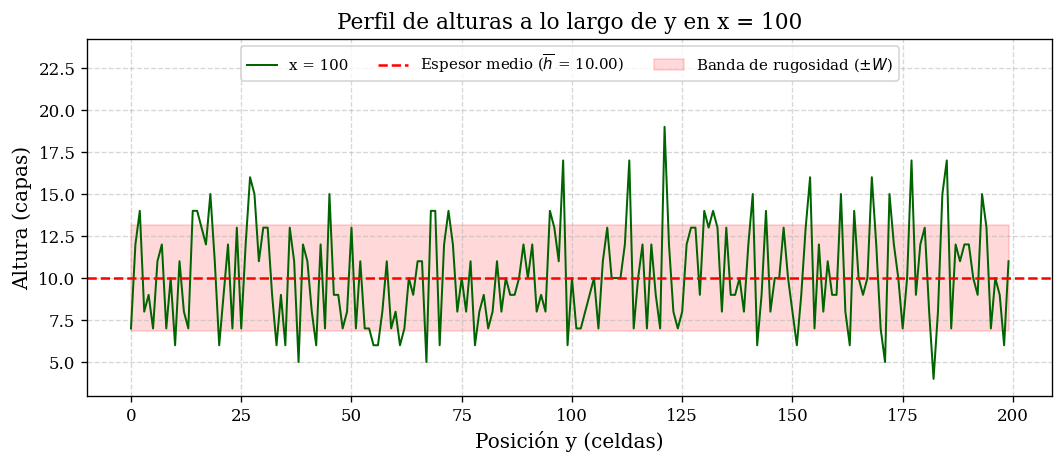

In [20]:
# Perfil unidimensional: alturas a lo largo de y en la coordenada x central
x_central = NX // 2
perfil = superficie_final[x_central, :]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(perfil, color="darkgreen", linewidth=1.2, label=f"x = {x_central}")
ax.axhline(
    espesor_sim,
    color="red",
    linestyle="--",
    label=rf"Espesor medio ($\overline{{h}}$ = {espesor_sim:.2f})",
)
ax.fill_between(
    range(NY),
    espesor_sim - rugosidad_sim,
    espesor_sim + rugosidad_sim,
    color="red",
    alpha=0.15,
    label=r"Banda de rugosidad ($\pm W$)",
)
ax.set_title(f"Perfil de alturas a lo largo de y en x = {x_central}")
ax.set_xlabel("Posición y (celdas)")
ax.set_ylabel("Altura (capas)")
ax.grid(True, linestyle="--", alpha=0.5)
# Margen superior para que la leyenda no tape el perfil.
ax.set_ylim(perfil.min() - 1, perfil.max() + 0.35 * (perfil.max() - perfil.min()))
ax.legend(loc="upper center", ncol=3, fontsize=9)
fig.tight_layout()
fig.savefig("rd_perfil_unidimensional.png", bbox_inches="tight")
plt.show()

## 8. Análisis de resultados

### 8.1 Conservación de partículas y espesor medio

El espesor medio simulado coincide con $N/(N_x N_y) = 10$ capas y su error relativo es nulo. Se trata de una identidad y no de una prueba estadística: cada evento añade exactamente una capa, de modo que la suma de las alturas es $N$ por construcción. La comparación funciona como control de calidad del código, ya que confirma que ninguna partícula se pierde ni se registra dos veces, y la ejecución verifica además de forma explícita que $\sum h = N$.

### 8.2 Rugosidad y estadística de Poisson

La rugosidad simulada se compara con $W_{\mathrm{teo}} = \sqrt{10} \approx 3.16$ capas. Una sola realización no reproduce este valor de manera exacta, pues fluctúa con una desviación típica $\sigma_W \approx 0.011$ capas ($0.35\,\%$). Por esa razón el error relativo no es por sí solo un criterio de aceptación: se emplea la desviación $z$ definida en la sección 6. Un $|z|$ pequeño indica que la diferencia es atribuible al muestreo, mientras que un $|z|$ grande señalaría un sesgo del generador o un error del algoritmo. La salida de la sección 6 informa el valor de $z$ y el resultado del criterio.

El histograma de alturas complementa esta comprobación. Las frecuencias simuladas se comparan con la distribución de Poisson de media $\lambda = 10$, que es asimétrica (coeficiente de asimetría $1/\sqrt{\lambda} \approx 0.32$). Por esa asimetría, el límite gaussiano también representado se aparta de la distribución de Poisson en las colas: sobrestima la de alturas bajas y subestima la de alturas altas.

### 8.3 Extremos de altura

Aunque el espesor medio es de 10 capas, la superficie contiene celdas con alturas muy alejadas de la media. Estos extremos no requieren ningún mecanismo adicional, porque son las colas de la distribución de Poisson. Para $\lambda = 10$ y $M = 4 \times 10^4$ celdas se esperan $M e^{-\lambda} \approx 1.8$ celdas vacías y unas dos celdas con 25 capas o más. La salida de la sección 6 contrasta estos conteos con los observados.

La rugosidad crece porque las alturas de las celdas son procesos de conteo independientes: la varianza de cada una aumenta linealmente con el número de partículas recibidas y ningún mecanismo redistribuye material entre celdas vecinas. Tampoco hay realimentación. En cada evento todas las celdas son equiprobables sin importar su altura ni su historia, de modo que una celda que recibió más partículas al inicio no tiene mayor probabilidad de recibir las siguientes. En una película real, procesos como la difusión superficial reducen estas fluctuaciones, y este es el motivo por el que se introducen los modelos con relajación.

## 9. Conclusiones

* El modelo de deposición aleatoria se implementó sobre una malla bidimensional SOS con un ciclo Monte Carlo que se compila con Numba cuando está disponible y que registra la evolución temporal del espesor medio y de la rugosidad RMS.

* El espesor medio coincide con $N/(N_x N_y)$ por conservación del número de partículas. La rugosidad se compara con $\sqrt{\overline{h}}$ mediante un criterio estadístico basado en la fluctuación esperada de una realización, y la distribución de alturas se contrasta con la distribución de Poisson de media $\overline{h}$.

* Sin mecanismos de relajación, la rugosidad crece indefinidamente como $\overline{h}^{1/2}$ y aparecen columnas altas y celdas vacías. El modelo tiende a sobrestimar la rugosidad de una película real, en la que la difusión superficial suaviza el relieve. Este resultado motiva el siguiente cuaderno de la serie, que incorpora la relajación superficial.

## 10. Referencias

**Fuentes académicas primarias**

* Barabási, A.-L., & Stanley, H. E. (1995). *Fractal concepts in surface growth*. Cambridge University Press.

* Family, F., & Vicsek, T. (1985). Scaling of the active zone in the Eden process on percolation networks and the ballistic deposition model. *Journal of Physics A: Mathematical and General, 18*(2), L75–L81. https://doi.org/10.1088/0305-4470/18/2/005

* Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., ... Oliphant, T. E. (2020). Array programming with NumPy. *Nature, 585*(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

* Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

* Lam, S. K., Pitrou, A., & Seibert, S. (2015). Numba: A LLVM-based Python JIT compiler. En *Proceedings of the Second Workshop on the LLVM Compiler Infrastructure in HPC* (LLVM '15) (Artículo 7, pp. 1–6). Association for Computing Machinery. https://doi.org/10.1145/2833157.2833162

* Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., ... SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods, 17*(3), 261–272. https://doi.org/10.1038/s41592-019-0686-2

**Recursos complementarios**

* Numba. (s. f.). *Supported NumPy features*. Numba documentation. https://numba.pydata.org/numba-doc/latest/reference/numpysupported.html